In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import math


In [40]:
file_wt = "J:/test/param_set_WT_DIMER_stats.parquet"
file_w10a = "J:/test/param_set_W10A_MONOMER_stats.parquet"
file_oe = "J:/test/param_set_WT_NANOG_OE_stats.parquet"
out_his = "feature_histograms_wt.png"
target_columns_wt = [
    "mean_mrna", 
    "mrna_fano", 
    "mrna_coefficient_of_variation", 
    "MFPT_NANOGb:SOX2f", 
    "MFPT_SOX2b:NANOGf", 
    "MFPT_SOX2b",
    "MFPT_NANOGb:NANOGf"
]
target_columns_w10a = [
    "mean_mrna", 
    "mrna_fano", 
    "mrna_coefficient_of_variation", 
    "MFPT_NANOGb", 
    "MFPT_SOX2b"
]
x_labels_wt = ["mrna count", "fano", "coefficient of variation", "MFPT (s)", "MFPT (s)", "MFPT (s)"]
x_labels_w10a = ["mrna count", "fano", "coefficient of variation", "MFPT (s)", "MFPT (s)"]

analytical_wt = {
    "MFPT_NANOGb:SOX2f": 23.38235294117647,  
    "MFPT_SOX2b:NANOGf": 24.16176470588235,  
    "MFPT_SOX2b": 16.6666666667,          
    "MFPT_NANOGb": (1/0.2),
    "MFPT_Heterodimer": 25.34461597610386
}

def plot_feature_histograms(parquet_path: str, target_columns: list, x_labels: list, analytical_expectations: dict = None, save_path: str = None):
    """
    Reads a parquet file and plots histograms for specific MFPT, Dwell, and mRNA features,
    with an optional vertical line for expected analytical values.
    
    Args:
        parquet_path (str): Path to the input .parquet file.
        target_columns (list): List of column names to plot.
        x_labels (list): X-axis labels corresponding to the target columns.
        analytical_expectations (dict, optional): Dictionary mapping column names to their analytical expected values.
        save_path (str, optional): If provided, saves the plot to this path. Otherwise, shows it.
    """
    # 1. Read the parquet file into a Pandas DataFrame
    df = pd.read_parquet(parquet_path)
    
    # 2. Define the exact columns you want to plot
    # Check which columns actually exist in the dataframe to avoid KeyErrors
    existing_cols = [col for col in target_columns if col in df.columns]
    missing_cols = [col for col in target_columns if col not in df.columns]
    
    if missing_cols:
        print(f"Warning: The following columns were not found and will be skipped: {missing_cols}")
        
    num_plots = len(existing_cols)
    if num_plots == 0:
        print("No target columns found in the dataset.")
        return

    cols_per_row = 3
    num_rows = math.ceil(num_plots / cols_per_row)
    
    fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(5 * cols_per_row, 4 * num_rows))
    
    # Handle the case where there is only one plot (axes is not an array)
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() 
    
    sns.set_theme(style="whitegrid")
    
    for i, col_name in enumerate(existing_cols):
        ax = axes[i]
        label = x_labels[i]
        
        sns.histplot(data=df, x=col_name, ax=ax, bins=30, kde=True, color="#8CC0EB")
        
        if analytical_expectations and col_name in analytical_expectations:
            expected_val = analytical_expectations[col_name]
            ax.axvline(x=expected_val, color='#767F9E', linestyle='--', linewidth=2.5, 
                       label=f'Analytical Expectation:  {expected_val:.2f}')
            ax.legend(loc='upper right')
        
        ax.set_title(col_name, fontsize=12)
        ax.set_xlabel(label)
        ax.set_ylabel("Counts")
        
    # Remove any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved successfully to {save_path}")
    else:
        plt.show()



Plot saved successfully to feature_histograms_wt.png


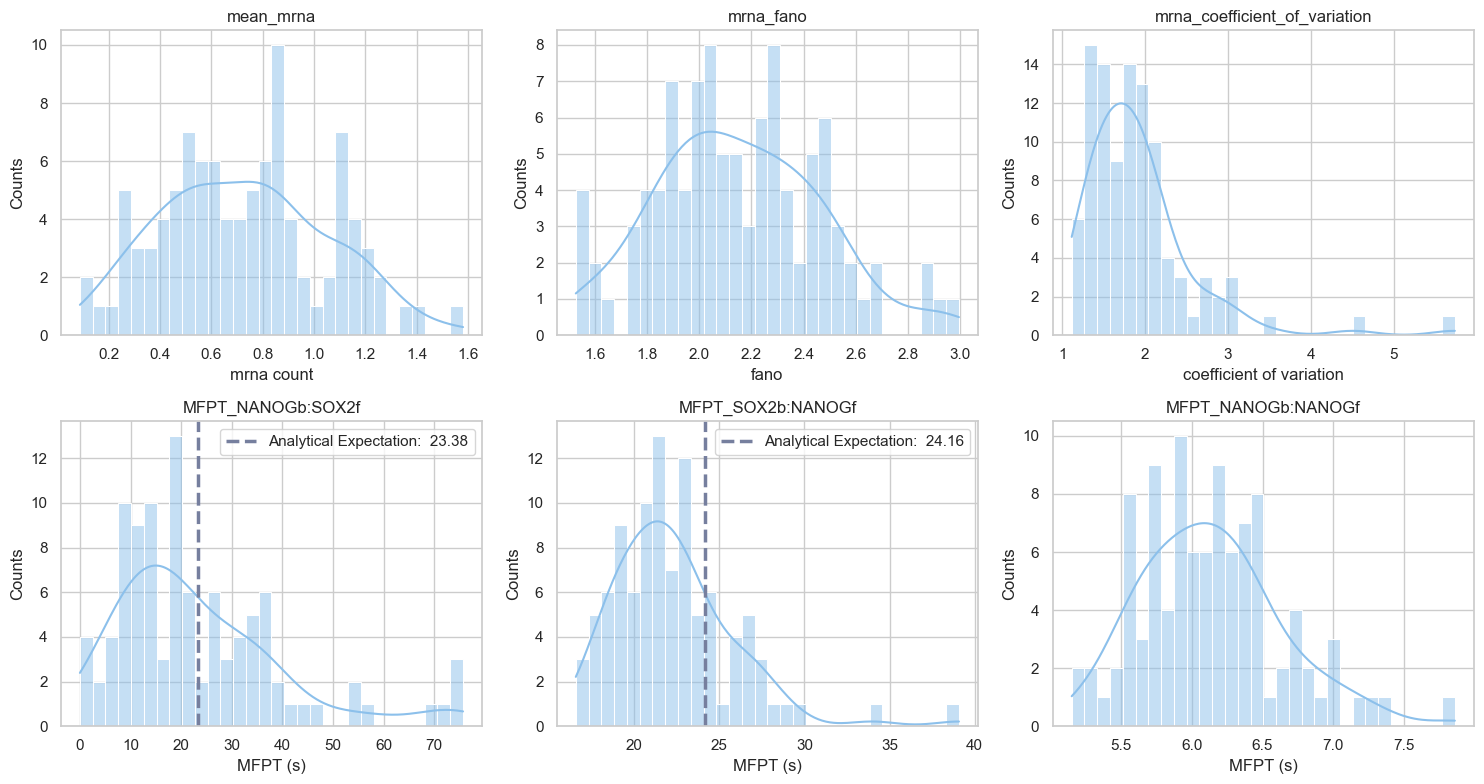

In [41]:
plot_feature_histograms(file_oe, target_columns_wt, x_labels_wt, save_path = out_his, analytical_expectations=analytical_wt)


Plot saved successfully to histogram_of_dimer_vs_monomer.png


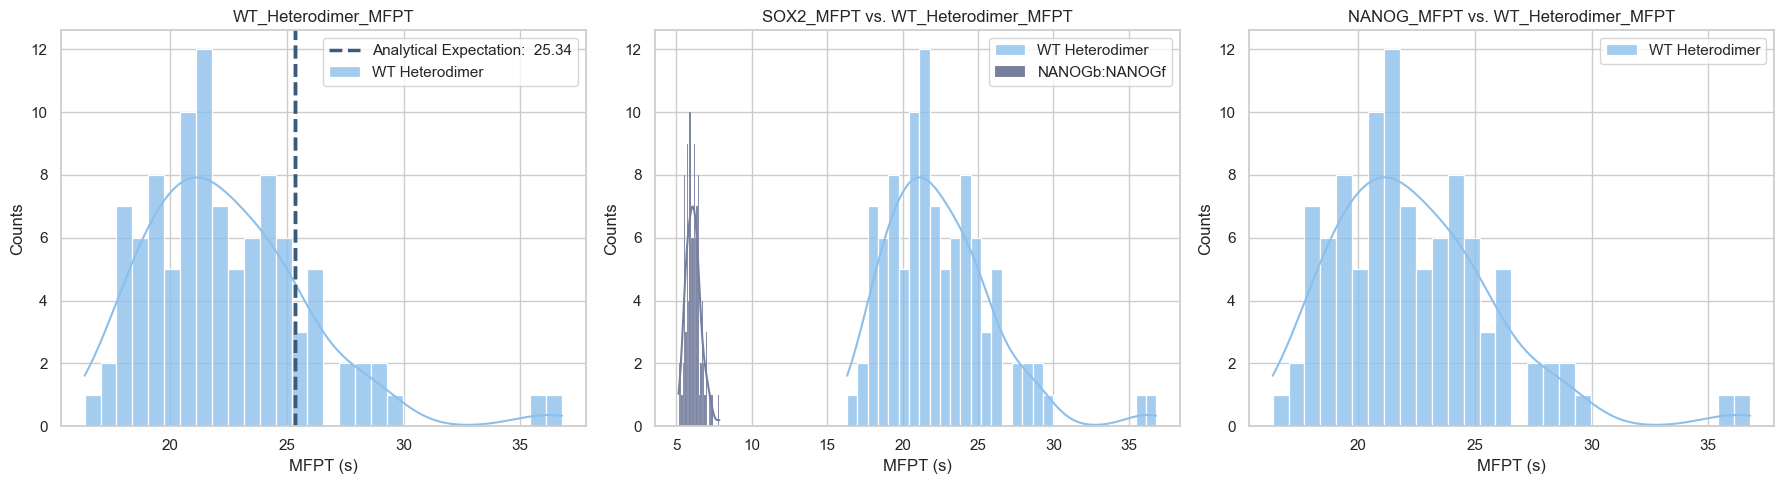

In [42]:
def compare_histograms(parquet_path1: str, parquet_path2: str, save_path: str = None, analytical_expectations: dict = None):
    """
    Reads WT and W10A parquet files, combines the dimer states, 
    and plots overlapping histograms to compare Dimers vs Monomers.
    
    Args:
        parquet_path1 (str): Path to the WT .parquet file.
        parquet_path2 (str): Path to the W10A .parquet file.
        save_path (str, optional): If provided, saves the plot to this path.
        analytical_expectations (dict, optional): Dictionary of expected analytical MFPTs.
    """
    # 1. Load the data using Polars
    df_wt = pl.read_parquet(parquet_path1)
    df_w10a = pl.read_parquet(parquet_path2)
    # 2. Calculate the combined MFPT for the Heterodimer in WT
    # Set up the figure
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ==========================================
    # PLOT 1: WT Heterodimer Only
    # ==========================================
    sns.histplot(x=df_wt["MFPT_Heterodimer"].to_numpy(), ax=axes[0], 
                 bins=30, kde=True, color="#8CC0EB", alpha=0.8, label="WT Heterodimer")
    
    if analytical_expectations and "MFPT_Heterodimer" in analytical_expectations:
        expected_val = analytical_expectations["MFPT_Heterodimer"]
        axes[0].axvline(x=expected_val, color='#3A5B7C', linestyle='--', linewidth=2.5, 
                        label=f'Analytical Expectation:  {expected_val:.2f}')

    axes[0].set_title("WT_Heterodimer_MFPT")
    axes[0].set_xlabel("MFPT (s)")
    axes[0].set_ylabel("Counts")
    axes[0].legend()

    # ==========================================
    # PLOT 2: SOX2 Monomers vs WT Heterodimer
    # ==========================================
    sns.histplot(x=df_wt["MFPT_Heterodimer"].to_numpy(), ax=axes[1], 
                 bins=30, kde=True, color="#8CC0EB", alpha=0.8, label="WT Heterodimer")
    
    if "MFPT_NANOGb:NANOGf" in df_wt.columns:
        sns.histplot(x=df_wt["MFPT_NANOGb:NANOGf"].to_numpy(), ax=axes[1], 
                     bins=30, kde=True, color="#767F9E", alpha=1, label="NANOGb:NANOGf")
        
    if "MFPT_SOX2b" in df_w10a.columns:
        sns.histplot(x=df_w10a["MFPT_SOX2b"].to_numpy(), ax=axes[1], 
                     bins=30, kde=True, color="#767F9E", alpha=0.5, label="W10A SOX2b (Monomer)")
    
    # Add Analytical Lines for Plot 2
    if analytical_expectations:
        if "MFPT_Heterodimer" in analytical_expectations:
            expected_val = analytical_expectations["MFPT_Heterodimer"]
            axes[0].axvline(x=expected_val, color='#3A5B7C', linestyle='--', linewidth=2.5, 
                            label=f'Analytical Heterodimer: {expected_val:.2f}')

    axes[1].set_title("SOX2_MFPT vs. WT_Heterodimer_MFPT")
    axes[1].set_xlabel("MFPT (s)")
    axes[1].set_ylabel("Counts")
    axes[1].legend()

    # ==========================================
    # PLOT 3: NANOG Monomers vs WT Heterodimer
    # ==========================================
    sns.histplot(x=df_wt["MFPT_Heterodimer"].to_numpy(), ax=axes[2], 
                 bins=30, kde=True, color="#8CC0EB", alpha=0.8, label="WT Heterodimer")
    
    if "MFPT_NANOGb" in df_wt.columns:
        sns.histplot(x=df_wt["MFPT_NANOGb"].to_numpy(), ax=axes[2], 
                     bins=30, kde=True, color="#DAA464", alpha=1, label="WT NANOGb (Monomer)")
        
    if "MFPT_NANOGb" in df_w10a.columns:
        sns.histplot(x=df_w10a["MFPT_NANOGb"].to_numpy(), ax=axes[2], 
                     bins=30, kde=True, color="#DAA464", alpha=0.5, label="W10A NANOGb (Monomer)")
        

    axes[2].set_title("NANOG_MFPT vs. WT_Heterodimer_MFPT")
    axes[2].set_xlabel("MFPT (s)")
    axes[2].set_ylabel("Counts")
    axes[2].legend()

    plt.tight_layout()
    
    # Save or Show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved successfully to {save_path}")
    else:
        plt.show()        
compare_histograms(file_oe, file_wt, analytical_expectations=analytical_wt, save_path="histogram_of_dimer_vs_monomer.png")

Plot saved successfully to histogram_of_dimer_vs_monomer2.png


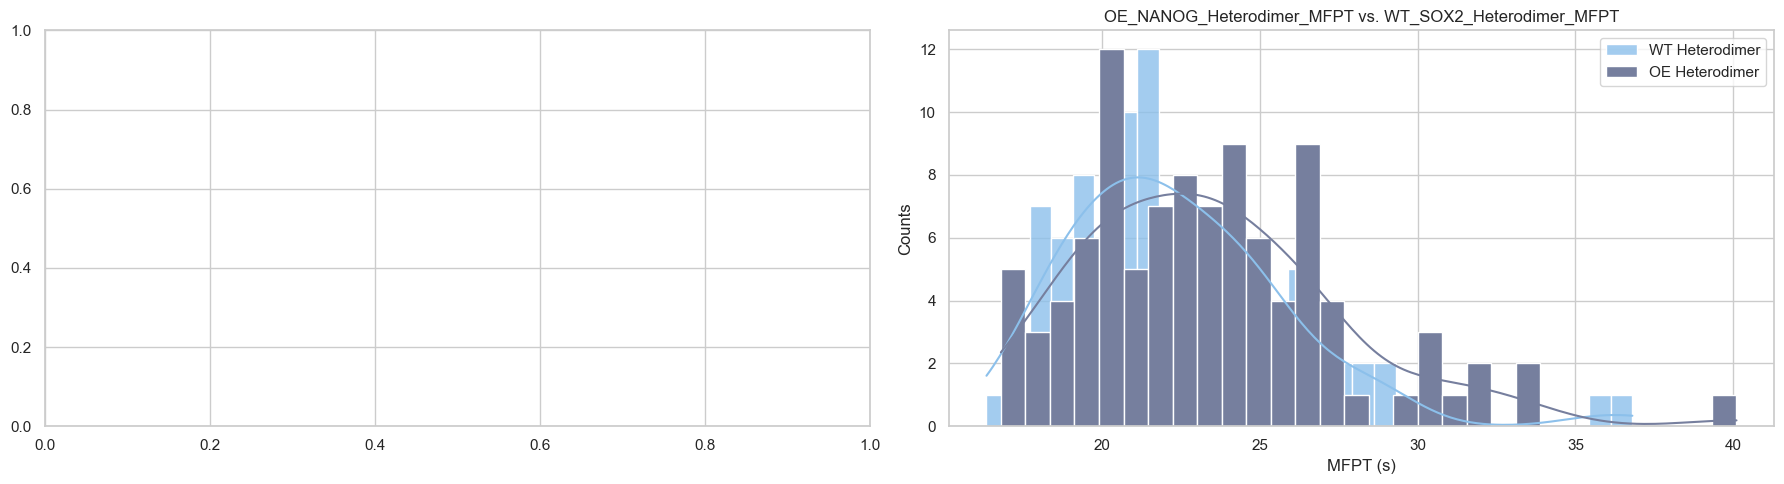

In [43]:
def compare_histograms(parquet_path1: str, parquet_path2: str, save_path: str = None, analytical_expectations: dict = None):
    """
    Reads WT and W10A parquet files, combines the dimer states, 
    and plots overlapping histograms to compare Dimers vs Monomers.
    
    Args:
        parquet_path1 (str): Path to the WT .parquet file.
        parquet_path2 (str): Path to the W10A .parquet file.
        save_path (str, optional): If provided, saves the plot to this path.
        analytical_expectations (dict, optional): Dictionary of expected analytical MFPTs.
    """
    # 1. Load the data using Polars
    df_wt = pl.read_parquet(parquet_path1)
    df_w10a = pl.read_parquet(parquet_path2)
    # 2. Calculate the combined MFPT for the Heterodimer in WT
    # Set up the figure
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    sns.histplot(x=df_wt["MFPT_Heterodimer"].to_numpy(), ax=axes[1], 
                 bins=30, kde=True, color="#8CC0EB", alpha=0.8, label="WT Heterodimer")
    
    if "MFPT_NANOGb:NANOGf" in df_wt.columns:
        sns.histplot(x=df_w10a["MFPT_Heterodimer"].to_numpy(), ax=axes[1], 
                     bins=30, kde=True, color="#767F9E", alpha=1, label="OE Heterodimer")
        
    

    axes[1].set_title("OE_NANOG_Heterodimer_MFPT vs. WT_SOX2_Heterodimer_MFPT")
    axes[1].set_xlabel("MFPT (s)")
    axes[1].set_ylabel("Counts")
    axes[1].legend()


    plt.tight_layout()
    
    # Save or Show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved successfully to {save_path}")
    else:
        plt.show()        
compare_histograms(file_oe, file_wt, analytical_expectations=analytical_wt, save_path="histogram_of_dimer_vs_monomer2.png")

In [ ]:
def compare_histograms(parquet_path1: str, parquet_path2: str, save_path: str = None, analytical_expectations: dict = None):
    """
    Reads WT and W10A parquet files, combines the dimer states, 
    and plots overlapping histograms to compare Dimers vs Monomers.
    
    Args:
        parquet_path1 (str): Path to the WT .parquet file.
        parquet_path2 (str): Path to the W10A .parquet file.
        save_path (str, optional): If provided, saves the plot to this path.
        analytical_expectations (dict, optional): Dictionary of expected analytical MFPTs.
    """
    # 1. Load the data using Polars
    df_wt = pl.read_parquet(parquet_path1)
    df_w10a = pl.read_parquet(parquet_path2)
    # 2. Calculate the combined MFPT for the Heterodimer in WT
    # Set up the figure
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    sns.histplot(x=df_wt["MFPT_Heterodimer"].to_numpy(), ax=axes[1], 
                 bins=30, kde=True, color="#8CC0EB", alpha=0.8, label="WT Heterodimer")
    
    if "MFPT_NANOGb:NANOGf" in df_wt.columns:
        sns.histplot(x=df_w10a["MFPT_Heterodimer"].to_numpy(), ax=axes[1], 
                     bins=30, kde=True, color="#767F9E", alpha=1, label="OE Heterodimer")
        
    

    axes[1].set_title("OE_NANOG_Heterodimer_MFPT vs. WT_SOX2_Heterodimer_MFPT")
    axes[1].set_xlabel("MFPT (s)")
    axes[1].set_ylabel("Counts")
    axes[1].legend()


    plt.tight_layout()
    
    # Save or Show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved successfully to {save_path}")
    else:
        plt.show()        
compare_histograms(file_oe, file_wt, analytical_expectations=analytical_wt, save_path="histogram_of_dimer_vs_monomer2.png")